# Changepoint Detection

什么是变点检测？

**变点检测是识别序列数据中生成参数发生突然变化的过程。**

通俗来说，假设你有一段数据，比如一个股票价格序列。如果市场因为某些事件发生了显著变化（如经济危机、突发新闻），股票的行为可能突然从“缓慢上涨”转变为“剧烈波动”。这个转折点就是一个 变点。变点检测的目标就是找到这些关键点。

In [1]:
# Necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ysy_plot_test_version as ypu

# Plot settings
plt.rcParams.update(ypu.ysy_settings())

In [2]:
# Load data
data = pd.read_csv('CPD_test_data.csv')
data

,Time(s),CH1(V),CH2(V)
0,-0.02962,-0.411661,3.288802
1,-0.02962,-0.205830,3.288802
2,-0.02962,-0.411661,3.208587
3,-0.02962,-0.205830,3.288802
4,-0.02962,0.000000,3.369017
...,...,...,...
999995,0.07038,-0.411661,3.288802
999996,0.07038,-0.205830,3.208587
999997,0.07038,0.000000,3.288802
999998,0.07038,-0.205830,3.369017


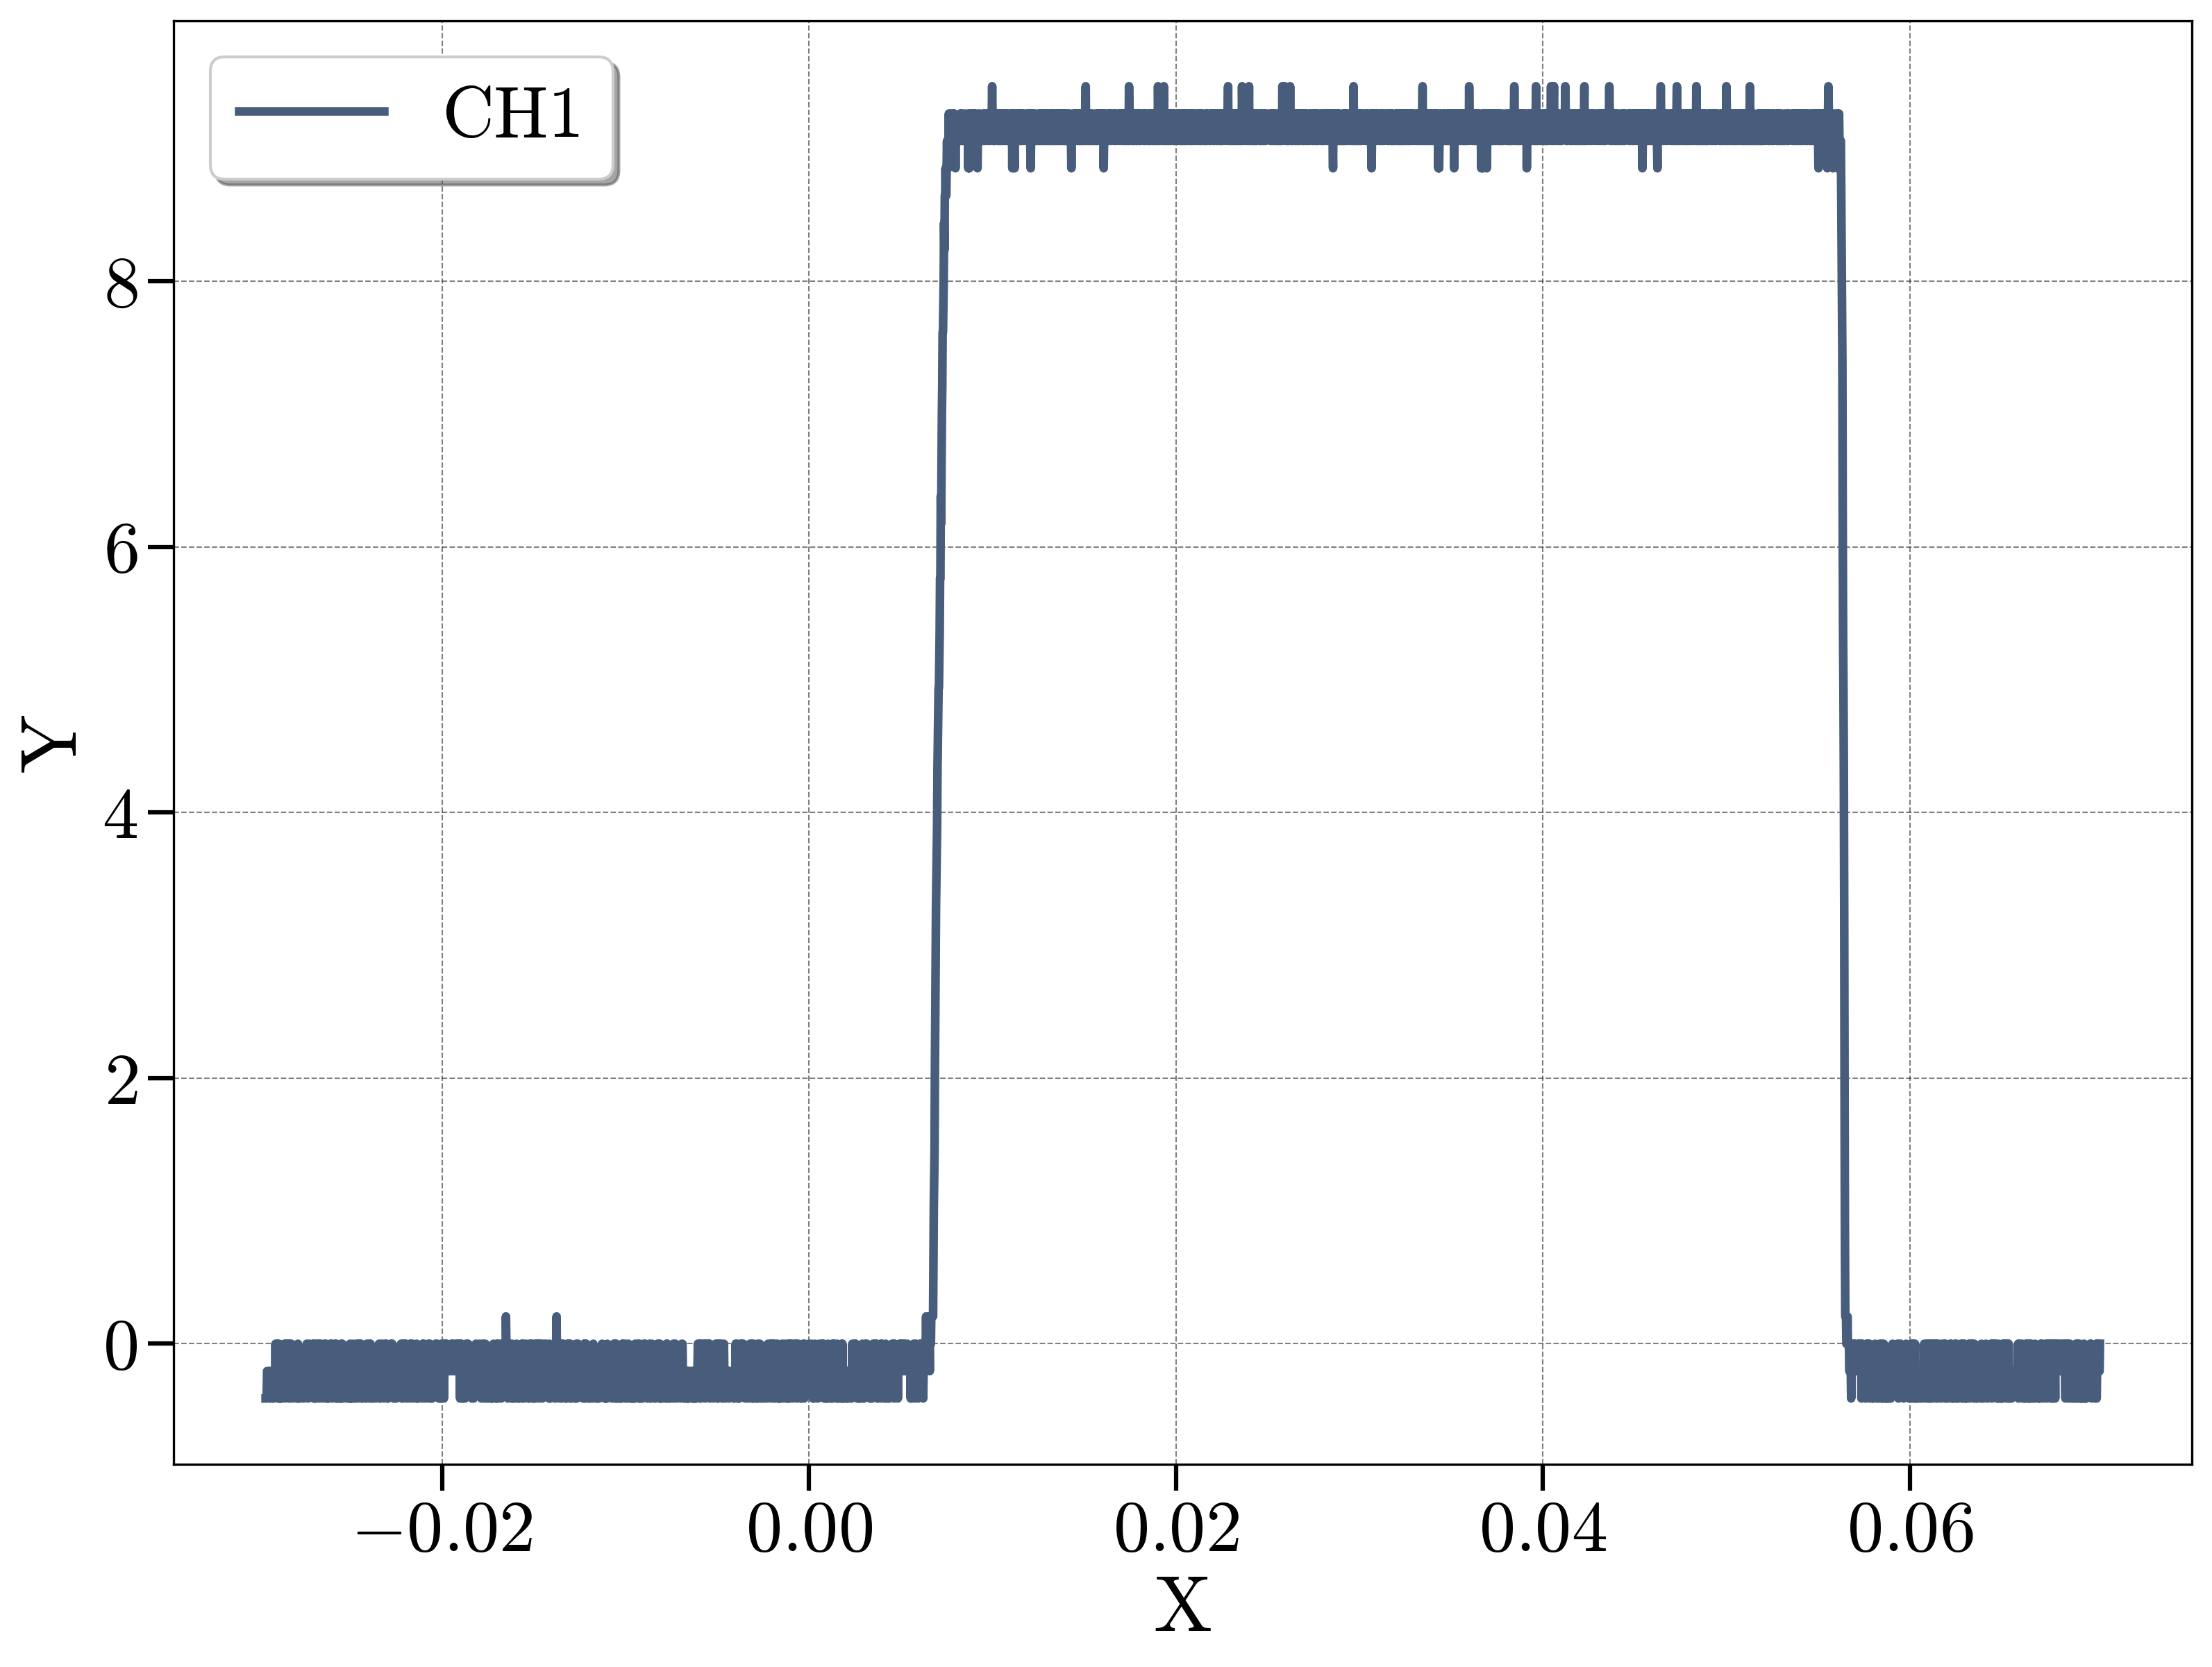

In [3]:
# Visualization
ch1 = data['CH1(V)'].values[::200]
time = data['Time(s)'].values[::200]
ypu.plot(time, ch1, 'CH1')

In [4]:
# Pre-analysis
print('Total: ',len(ch1))
print('High', len(ch1[ch1>8]))

Total:  5000
High 2448


## Method1: Bayesian Online Changepoint Detection (BOCPD)

贝叶斯在线变点检测将是本专题主要讲解的一种方法。

参考文献（也是这一方法的出处）：https://arxiv.org/abs/0710.3742

---

在线（online）检测：数据一边产生，你一边分析。你不能回顾过去的数据，只能用已经观察到的数据进行判断。适用于实时决策的场景，比如机器人导航：环境随时可能发生变化，机器人需要立即判断是否要改变策略。  
离线（offline）检测：先拿到所有的数据，然后再慢慢回顾和分析变点。适用于回顾性分析，比如总结过去几十年气候变化的趋势。

**我们假设观察序列可以被划分为多个不重叠的段，每一段中的数据是独立同分布的。**

目标：实时估计当前段的长度（运行长度，run length）：即从最近一个变点到当前时刻之间的时间长度。通过这个运行长度，推断接下来的数据会是什么样子。

In [ ]:
后续计划：
1.继续完善BOCPD（本专题主要内容）
2.介绍其它方法通过调用现成的库怎么使用（关键词：ruptures）